# Персонализация доставки в Яндекс Еде

Идея проекта: быстрая доставка стоит дороже для компании, поэтому невыгодно ускорять все заказы одинаково. При этом сводить все к скорости нельзя — часть клиентов уходит не из-за долгого ожидания, а из-за других причин. 

В проекте решается две задачи:

1. Определение пользователей, для которых рационально использовать ускоренную доставку;
2. Распознание ситуаций, в которых есть риск потери клиента.

In [120]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import TruncatedSVD

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from reviews_parser import delivery_review_parser

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

## Данные

В проекте используется три источника данных:
1. `food_delivery_survey.csv` — открытый датасет с результатами опроса о предпочтениях в доставке еды. Взят с [kaggle](https://www.kaggle.com/datasets/adtech1234/food-delivery-data)
2. `yandex_food_google_play_reviews_parsed.csv` — отзывы для приложения "Яндекс Еда" из Google Play, касающиеся даставки. Собран с помощью [reviews_parser.py](./reviews_parser.py)
3. `delivery_club_google_play_reviews_parsed.csv` — то же для Delivery Club.

In [121]:
data = pd.read_csv("food_delivery_survey.csv")
data.columns = data.columns.str.strip()

for column in data.select_dtypes(include="object").columns:
    data[column] = data[column].astype(str).str.strip()

data.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,City,Family size,Medium (P1),Medium (P2),...,Less Delivery time,High Quality of package,Number of calls,Politeness,Freshness,Temperature,Good Taste,Good Quantity,Output,Reviews
0,20,Female,Single,Student,No Income,Post Graduate,Brisbane,4,Food delivery apps,Web browser,...,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Moderately Important,Yes,Nil
1,24,Female,Single,Student,Below Rs.10000,Graduate,Adelaide,3,Food delivery apps,Web browser,...,Very Important,Very Important,Very Important,Very Important,Very Important,Very Important,Very Important,Very Important,Yes,Nil
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,Melbourne,3,Food delivery apps,Direct call,...,Important,Very Important,Moderately Important,Very Important,Very Important,Important,Very Important,Moderately Important,Yes,"Many a times payment gateways are an issue, so..."
3,22,Female,Single,Student,No Income,Graduate,Melbourne,6,Food delivery apps,Walk-in,...,Very Important,Important,Moderately Important,Very Important,Very Important,Very Important,Very Important,Important,Yes,nil
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,Adelaide,4,Walk-in,Direct call,...,Important,Important,Moderately Important,Important,Important,Important,Very Important,Very Important,Yes,NIL


In [122]:
print("строк:", data.shape[0])
print("столбцов:", data.shape[1])
print("пропусков:", int(data.isna().sum().sum()))
print("дубликатов:", int(data.duplicated().sum()))

data = data.drop_duplicates().reset_index(drop=True)
print("осталось строк:", data.shape[0])

строк: 388
столбцов: 53
пропусков: 1
дубликатов: 25
осталось строк: 363


In [123]:
# Удаляем дубликаты
data = data.drop_duplicates().reset_index(drop=True)
print("осталось строк после удаления дубликатов:", data.shape[0])

осталось строк после удаления дубликатов: 363


In [124]:
# Выводим все возможные значения текстовых колонок
for column in ["Output", "Maximum wait time", "Less Delivery time", "Late Delivery", "Occupation"]:
    print(data[column].value_counts(), end="\n\n")

Output
Yes    283
No      80
Name: count, dtype: int64

Maximum wait time
45 minutes              142
30 minutes              130
15 minutes               37
60 minutes               33
More than 60 minutes     21
Name: count, dtype: int64

Less Delivery time
Important               229
Very Important           56
Moderately Important     42
Slightly Important       31
Unimportant               5
Name: count, dtype: int64

Late Delivery
Agree                152
Neutral               79
Disagree              71
Strongly agree        31
Strongly disagree     30
Name: count, dtype: int64

Occupation
Student           198
Employee          106
Self Employeed     50
House wife          9
Name: count, dtype: int64



## Предобработка

Закодируем значения текстовых колонок с помощью label encoding там, где это релевантно (там, где текстовые значения соответствуют шкалам).

In [125]:
agreement_map = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly agree": 5,
    "Strongly Agree": 5,
}
importance_map = {
    "Unimportant": 1,
    "Slightly Important": 2,
    "Moderately Important": 3,
    "Important": 4,
    "Very Important": 5,
}
yes_map = {"No": 0, "Maybe": 1, "Yes": 2}
wait_map = {
    "15 minutes": 15,
    "30 minutes": 30,
    "45 minutes": 45,
    "60 minutes": 60,
    "More than 60 minutes": 75,
}

In [126]:
prepared = data.copy()

scale_maps = {"agreement": agreement_map, "importance": importance_map, "yes_no_maybe": yes_map}
scale_columns_count = {name: 0 for name in scale_maps}
scale_columns = []

# Находим все колонки, значения которых можно заменить на числовые. 
for column in data.columns:
    if column == "Output":
        continue  # Output задает целевую переменную, кодировать его в признак нельзя
    values = set(data[column].dropna().unique())
    for scale_name, scale_map in scale_maps.items():
        if values and values.issubset(set(scale_map)):
            prepared[column + ' num'] = prepared[column].map(scale_map)
            scale_columns_count[scale_name] += 1
            scale_columns.append(column)
            break

prepared["wait minutes"] = prepared["Maximum wait time"].map(wait_map)
prepared["continue target"] = prepared["Output"].map({"No": 0, "Yes": 1})

# количество закодированных колонок
print(*scale_columns_count.items(), sep='\n')

('agreement', 25)
('importance', 8)
('yes_no_maybe', 2)


Анкета слишком подробная — несколько вопросов по сути об одном и том же. Сворачиваем близкие пункты в три показателя, чтобы у модели был не только сырой ответ, но и обобщенный сигнал: ценность сервиса, проблемы с доставкой и ожидания от заказа.

In [127]:
service_columns = ["Ease and convenient num", "Time saving num", "More restaurant choices num", "Easy Payment option num", "More Offers and Discount num"]
delivery_problem_columns = ["Late Delivery num", "Long delivery time num", "Delay of delivery person getting assigned num", "Delay of delivery person picking up food num"]
order_expectation_columns = ["High Quality of package num", "Freshness num", "Temperature num", "Good Taste num", "Good Quantity num"]

prepared["service value"] = prepared[service_columns].mean(axis=1)
prepared["delivery problems"] = prepared[delivery_problem_columns].mean(axis=1)
prepared["order expectations"] = prepared[order_expectation_columns].mean(axis=1)

Теперь целевые переменные.

1. Ускорение доставки нужно тем, кто не готов долго ждать (`wait minutes <= 30`) и отмечает скорость как важный параметр (`Less Delivery time >= 4`). 
2. Клиенты, которые потенциально могут отказаться от сервиса — те, у которых `continue target == 0`.

Обе метки синтетические. Настоящего факта ухода клиента в анкете нет, мы восстанавливаем его из других ответов.

In [128]:
prepared["accelerated target"] = np.where(
    (prepared["wait minutes"] <= 30) & (prepared["Less Delivery time num"] >= 4), 1, 0
)
prepared["dissatisfaction target"] = np.where(prepared["continue target"] == 0, 1, 0)
prepared["delivery class"] = np.where(prepared["accelerated target"] == 1, "fast", "standard")

prepared[["service value", "delivery problems", "order expectations", "wait minutes", "accelerated target", "dissatisfaction target"]].head()

,service value,delivery problems,order expectations,wait minutes,accelerated target,dissatisfaction target
0,3.0,3.75,3.0,30,0,0
1,5.0,4.75,5.0,30,1,0
2,4.2,3.75,4.4,45,0,0
3,4.4,3.75,4.6,30,1,0
4,4.0,4.50,4.4,30,1,0


## Признаки из текста отзыва

В опросе есть поле `Reviews` со свободным текстом, а отзывы из Google Play — это только текст и оценка. Для их одинаковой обработки был создан скрипт `reviews_parser.py`. Парсер определяет упомянутое время доставки и негативную направленность отзывов. 

Рассмотрим его работу на примере:

In [129]:
examples = pd.Series([
    "Курьер приехал за 20 минут, все супер",
    "Ждали доставку полтора часа, еда остыла",
    "Very fast delivery, got everything in 25 minutes",
    "The courier was late and food was cold",
    "Nil",
    "Вкусно, но про доставку ничего не скажу",
], name="review")

pd.concat([examples, examples.apply(delivery_review_parser)], axis=1)

,review,review_has_text,mentions_delivery_time,delivery_time_minutes,delivery_time_sentiment,delivery_time_score,delivery_time_complaint,delivery_time_praise
0,"Курьер приехал за 20 минут, все супер",1,1,20.0,positive,1,0,1
1,"Ждали доставку полтора часа, еда остыла",1,1,90.0,negative,-1,1,0
2,"Very fast delivery, got everything in 25 minutes",1,1,25.0,positive,1,0,1
3,The courier was late and food was cold,1,1,NaN,negative,-1,1,0
4,Nil,0,0,NaN,no_review,0,0,0
5,"Вкусно, но про доставку ничего не скажу",1,1,NaN,neutral,0,0,0


In [130]:
review_features = prepared["Reviews"].apply(delivery_review_parser)
prepared = pd.concat([prepared, review_features], axis=1)

prepared.loc[
    prepared["mentions_delivery_time"] == 1,
    ["Reviews", "delivery_time_minutes", "delivery_time_sentiment", "delivery_time_complaint"],
].head(8)

,Reviews,delivery_time_minutes,delivery_time_sentiment,delivery_time_complaint
11,Language barrier is also one major issue. Mosl...,NaN,neutral,0
18,Once my order from kfc got exchanged with some...,NaN,neutral,0
22,I feel Swiggy has a good interface for users a...,NaN,neutral,0
32,I expect faster delivery in my area,NaN,positive,0
36,Now days delivery ?? is improved a lot like fa...,NaN,positive,0
37,I love zomato but it requires quality in deliv...,NaN,neutral,0
40,Prefer hygienic delivery people,NaN,neutral,0
88,Now days delivery ?? is improved a lot like fa...,NaN,positive,0


In [131]:
# проверка: чем хуже отношение к доставке, тем реже клиент готов остаться
prepared.groupby("delivery_time_sentiment").agg(
    reviews=("Reviews", "count"),
    continue_rate=("continue target", "mean"),
    accelerated_rate=("accelerated target", "mean"),
).round(3).sort_values("reviews", ascending=False)

,reviews,continue_rate,accelerated_rate
delivery_time_sentiment,,,
no_review,142,0.944,0.371
no_mention,89,0.831,0.404
neutral,78,0.590,0.372
positive,36,0.639,0.417
negative,17,0.294,0.588


## Отзывы из Google Play

Подключаем два собранных датасета. В обоих оставлены только отзывы про доставку. Одинаковые тексты отзывов (дубикаты) убираем.

In [132]:
google_reviews = pd.read_csv("yandex_food_google_play_reviews_parsed.csv")
delivery_club_reviews = pd.read_csv("delivery_club_google_play_reviews_parsed.csv")

google_reviews["source"] = "Яндекс Еда"
delivery_club_reviews["source"] = "Delivery Club"

review_columns = [
    "source", "rating", "review", "review_has_text", "mentions_delivery_time", "delivery_time_minutes",
    "delivery_time_sentiment", "delivery_time_score", "delivery_time_complaint", "delivery_time_praise",
]

external_reviews = pd.concat(
    [google_reviews[review_columns], delivery_club_reviews[review_columns]], ignore_index=True
)
external_reviews = external_reviews.drop_duplicates(subset="review").reset_index(drop=True)
external_reviews.shape

(5822, 10)

In [133]:
external_reviews.groupby("source").agg(
    reviews=("review", "count"),
    complaints=("delivery_time_complaint", "sum"),
    praises=("delivery_time_praise", "sum"),
    average_rating=("rating", "mean"),
).round(3)

,reviews,complaints,praises,average_rating
source,,,,
Delivery Club,2902,775,1032,2.800
Яндекс Еда,2920,775,1096,2.822


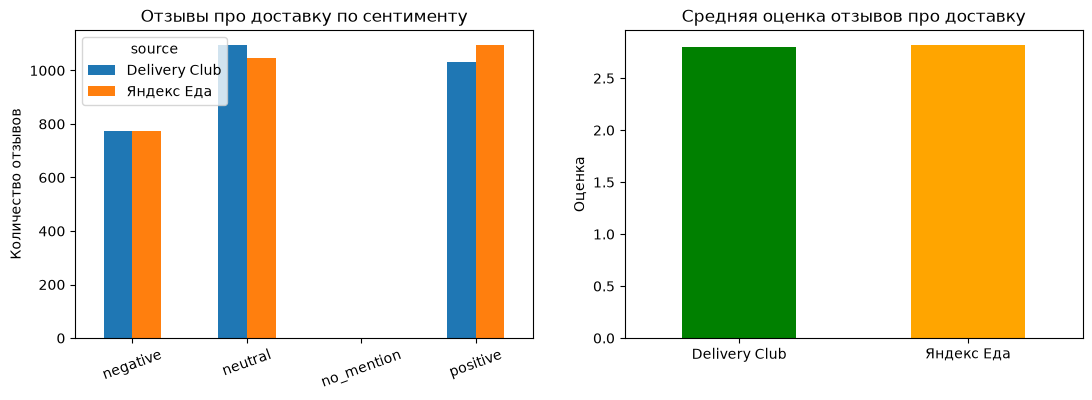

In [134]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sentiment_table = external_reviews.pivot_table(
    index="delivery_time_sentiment", columns="source", values="review", aggfunc="count", fill_value=0
)
sentiment_table.plot(kind="bar", ax=axes[0])
axes[0].set(title="Отзывы про доставку по сентименту", xlabel="", ylabel="Количество отзывов")
axes[0].tick_params(axis="x", rotation=20)

external_reviews.groupby("source")["rating"].mean().plot(kind="bar", ax=axes[1], color=["green", "orange"])
axes[1].set(title="Средняя оценка отзывов про доставку", xlabel="", ylabel="Оценка")
axes[1].tick_params(axis="x", rotation=0)

plt.show()

У двух сервисов картина почти одинаковая: похожая доля жалоб и средняя оценка около 2.8. Значит, объединенный датасет не перекошен в сторону одного из них, и обучать модель на нем можно.

Целевые переменные на отзывах строим по той же логике, что и на опросе: необходимость ускорения доставки — это негативная упоминание доставки при оценке не выше 3; риск потери клиента — оценка 1–2.

In [135]:
external_reviews["accelerated target"] = np.where(
    (external_reviews["delivery_time_sentiment"] == "negative") & (external_reviews["rating"] <= 3), 1, 0
)
external_reviews["dissatisfaction target"] = np.where(external_reviews["rating"] <= 2, 1, 0)

external_reviews.groupby("source").agg(
    reviews=("review", "count"),
    accelerated_share=("accelerated target", "mean"),
    dissatisfaction_share=("dissatisfaction target", "mean"),
    mean_rating=("rating", "mean"),
).round(3)

,reviews,accelerated_share,dissatisfaction_share,mean_rating
source,,,,
Delivery Club,2902,0.251,0.537,2.800
Яндекс Еда,2920,0.252,0.533,2.822


"Сентимент" доставки парсер достает из текста, и тот же текст мы потом передаем модели. Поэтому высокие метрики текстовой модели частично означают, что она заново выучила словарь парсера, а не нашла независимый сигнал (в дальнейшем ее топ-слова дальше почти совпадут со словарем парсера). 

При решении реальной задачи целевую переменную надо размечать исходя из данных, не попадающих в признаки; например, только из оценки или из ручной разметки. Метка риска недовольства (оценка 1–2) этой проблемы не имеет, т.к. оценку модель не видит.

## EDA

Для бизнеса важны три цифры: сколько клиентов вообще готовы пользоваться сервисом, насколько для них критично короткое ожидание и для какой доли клиентов нужно использовать сценарий ускоренной доставки.

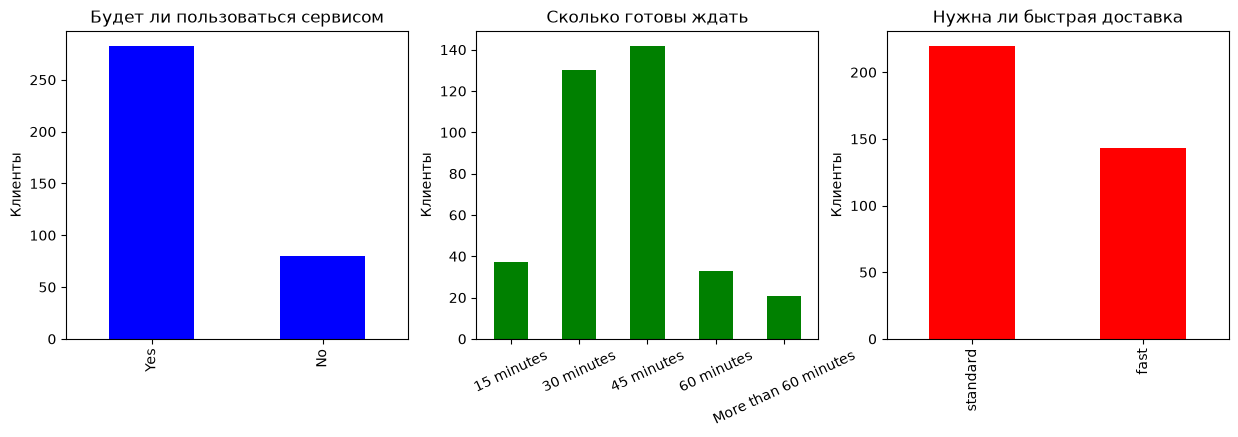

In [136]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

prepared["Output"].value_counts().plot(kind="bar", ax=axes[0], color="blue")
axes[0].set(title="Будет ли пользоваться сервисом", xlabel="", ylabel="Клиенты")

prepared["Maximum wait time"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="green")
axes[1].set(title="Сколько готовы ждать", xlabel="", ylabel="Клиенты")
axes[1].tick_params(axis="x", rotation=25)

prepared["delivery class"].value_counts().plot(kind="bar", ax=axes[2], color="red")
axes[2].set(title="Нужна ли быстрая доставка", xlabel="", ylabel="Клиенты")

plt.show()

In [137]:
prepared.groupby("delivery class").agg(
    clients=("Age", "count"),
    mean_age=("Age", "mean"),
    mean_wait=("wait minutes", "mean"),
    delivery_problems=("delivery problems", "mean"),
    service_value=("service value", "mean"),
    continue_rate=("continue target", "mean"),
).round(3)

,clients,mean_age,mean_wait,delivery_problems,service_value,continue_rate
delivery class,,,,,,
fast,143,24.503,26.538,3.561,3.536,0.678
standard,220,24.605,48.205,3.252,3.785,0.845


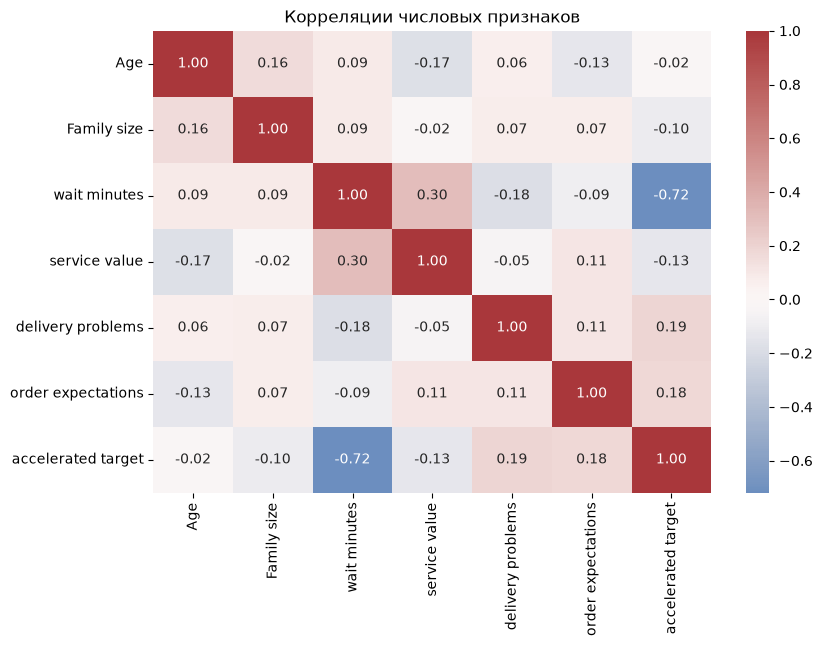

In [138]:
correlation_columns = ["Age", "Family size", "wait minutes", "service value", "delivery problems", "order expectations", "accelerated target"]

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(prepared[correlation_columns].corr(), annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set(title="Корреляции числовых признаков")
plt.show()

## Схема работы в продукте

Обе модели встраиваются в один поток:

![scheme.png](scheme.png)

## Признаки и пайплайны для моделей

В признаках опроса мы убираем все, что напрямую задает целевую переменную, а также исходные текстовые версии закодированных числами признаков.

In [139]:
survey_drop = [
    "Output", "continue target",          # источники метки недовольства
    "wait minutes", "Less Delivery time num", "Maximum wait time", "Less Delivery time",  # источники метки ускорения
    "Reviews", "accelerated target", "dissatisfaction target", "delivery class",
] + scale_columns

X_survey = prepared.drop(columns=[c for c in dict.fromkeys(survey_drop) if c in prepared.columns])
y_survey_accelerated = prepared["accelerated target"]
y_survey_dissatisfaction = prepared["dissatisfaction target"]

X_survey.shape

(363, 59)

In [140]:
def make_preprocessor(X):
    numeric = X.select_dtypes(include="number").columns.tolist()
    categorical = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
    return ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical),
    ])

SURVEY_K = 40  # сколько признаков оставляем после отбора

def survey_pipeline(model):
    return Pipeline([
        ("prep", make_preprocessor(X_survey)),
        ("select", SelectKBest(f_classif, k=SURVEY_K)),
        ("model", model),
    ])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [141]:
review_text = external_reviews["source"] + " " + external_reviews["review"].fillna("")
y_review_accelerated = external_reviews["accelerated target"]
y_review_dissatisfaction = external_reviews["dissatisfaction target"]

def review_pipeline(model, reduce_dim=False):
    steps = [("tfidf", TfidfVectorizer(min_df=2, ngram_range=(1, 2), max_features=4000))]
    if reduce_dim:
        # LSA: сжимаем разреженную TF-IDF матрицу до плотных тем, на которых работают деревья
        steps += [("svd", TruncatedSVD(n_components=200, random_state=RANDOM_STATE)), ("scale", StandardScaler())]
    steps.append(("model", model))
    return Pipeline(steps)

### Модели и трансформеры

Сравниваем модели разной природы на одних и тех же данных.

На опросе: логистическая регрессия, kNN, случайный лес, градиентный бустинг и многослойный перцептрон.

На отзывах: логистическая регрессия на TF-IDF, а случайный лес и перцептрон — на сжатом LSA-представлении.

Трансформеры в пайплайнах тоже разные: `SimpleImputer` (пропуски), `StandardScaler` (масштаб), `OneHotEncoder` (категории), `SelectKBest` (отбор признаков), `TfidfVectorizer` (векторизация текста) и `TruncatedSVD` / LSA (снижение размерности). 
Из отсутствующего в семинарах используем LSA поверх TF-IDF, permutation importance для интерпретации и PR-AUC (`average_precision`) как метрика для редкого класса.

In [142]:
survey_models = {
    "LogReg": survey_pipeline(LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    "KNN": survey_pipeline(KNeighborsClassifier()),
    "RandomForest": survey_pipeline(RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE)),
    "GradientBoosting": survey_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE)),
    "MLP": survey_pipeline(MLPClassifier(hidden_layer_sizes=(24, 12), max_iter=700, alpha=0.01, random_state=RANDOM_STATE)),
}

review_models = {
    "LogReg": review_pipeline(LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    "RandomForest+LSA": review_pipeline(RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1), reduce_dim=True),
    "MLP+LSA": review_pipeline(MLPClassifier(hidden_layer_sizes=(64,), max_iter=300, random_state=RANDOM_STATE), reduce_dim=True),
}

In [143]:
def compare_models(models, X, y, scoring, sort_by):
    rows = []
    for name, pipeline in models.items():
        scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        rows.append({"model": name, **{metric: scores["test_" + metric].mean() for metric in scoring}})
    return pd.DataFrame(rows).sort_values(sort_by, ascending=False).reset_index(drop=True).round(3)

## Задача 1. Кому нужна ускоренная доставка

Если модель относит пользователя или отзыв к этому классу, платформа выбирает более быстрый сценарий доставки. Классы несбалансированы, поэтому на датасете опроса смотрим на ROC-AUC, а на датасете с отзывами добавляем PR-AUC для редкого класса "ускорять"

In [144]:
survey_accelerated = compare_models(survey_models, X_survey, y_survey_accelerated, ["accuracy", "f1", "roc_auc"], "roc_auc")
survey_accelerated

,model,accuracy,f1,roc_auc
0,RandomForest,0.791,0.729,0.870
1,GradientBoosting,0.752,0.678,0.800
2,MLP,0.722,0.643,0.761
3,LogReg,0.661,0.606,0.700
4,KNN,0.628,0.537,0.672


In [145]:
review_accelerated = compare_models(review_models, review_text, y_review_accelerated, ["f1", "accuracy", "average_precision"], "f1")
review_accelerated

,model,f1,accuracy,average_precision
0,LogReg,0.779,0.873,0.879
1,MLP+LSA,0.772,0.887,0.853
2,RandomForest+LSA,0.687,0.828,0.729


На данных из опроса порядок устойчивый: `RandomForest > GradientBoosting > MLP > LogReg > KNN`. Деревья, бустинг и перцептрон ловят нелинейные связи между ответами, которых логрегрессия не видит. kNN слабее всех — он считает одну метрику расстояния по смешанным шкальным и one-hot признакам и плохо переносит дисбаланс.

На тексте все наоборот: лучше всего показала себя `LogReg`, `MLP+LSA` имеет примерно такие же характеристики, а `RandomForest+LSA` заметно проседает за счет потери важных слов при сжатие до 200 LSA-компонент.

Для дальнейшей работы будем использовать `RandomForest` на опросе и `LogReg` на отзывах.

## Задача 2. Риск недовольства или потери клиента

На опросе положительный класс — клиент не собирается продолжать пользоваться доставкой; на отзывах — оценка 1–2. Такой прогноз может понадобиться отделам поддержки и контроля качества.


In [146]:
survey_dissatisfaction = compare_models(survey_models, X_survey, y_survey_dissatisfaction, ["accuracy", "f1", "roc_auc"], "roc_auc")
survey_dissatisfaction

,model,accuracy,f1,roc_auc
0,GradientBoosting,0.934,0.851,0.954
1,RandomForest,0.937,0.853,0.947
2,MLP,0.917,0.809,0.947
3,LogReg,0.884,0.757,0.941
4,KNN,0.909,0.760,0.901


In [147]:
review_dissatisfaction = compare_models(review_models, review_text, y_review_dissatisfaction, ["accuracy", "f1", "roc_auc"], "f1")
review_dissatisfaction

,model,accuracy,f1,roc_auc
0,LogReg,0.922,0.929,0.972
1,MLP+LSA,0.915,0.922,0.965
2,RandomForest+LSA,0.906,0.914,0.955


Модели почти не отличаются по показателям. Лучше всего себя показывают градиентный бустинг на опросе и логистическая регрессия на отзывах. Тем не менее, для опроса возьмем случайный лес, чтобы всего 2 типа моделей рассматривать а не 3.

## Подбор гиперпараметров

Для финала настраиваем двух представителей разной природы — логистическую регрессию и случайный лес — под обе целевые переменные, по ROC-AUC. У логрегрессии перебираем силу регуляризации, у леса — глубину деревьев, минимальный размер листа и число деревьев. Под каждую задачу подбираем отдельно.

In [148]:
logreg_grid = {"model__C": [0.3, 1, 3], "model__solver": ["liblinear"]}
rf_grid = {"model__n_estimators": [200, 350], "model__max_depth": [4, 8, None], "model__min_samples_leaf": [1, 3]}

def tune(model, grid, y):
    search = GridSearchCV(survey_pipeline(model), grid, cv=cv, scoring="roc_auc", n_jobs=-1)
    search.fit(X_survey, y)
    return search

best_models = {}
tuning = []
for task, y in [("ускорение", y_survey_accelerated), ("недовольство", y_survey_dissatisfaction)]:
    logreg = tune(LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE), logreg_grid, y)
    forest = tune(RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE), rf_grid, y)
    best_models[task, "LogReg"] = logreg.best_estimator_
    best_models[task, "RandomForest"] = forest.best_estimator_
    tuning += [
        {"task": task, "model": "LogReg", "roc_auc": logreg.best_score_, "params": logreg.best_params_},
        {"task": task, "model": "RandomForest", "roc_auc": forest.best_score_, "params": forest.best_params_},
    ]

pd.DataFrame(tuning).round(3)

,task,model,roc_auc,params
0,ускорение,LogReg,0.709,"{'model__C': 0.3, 'model__solver': 'liblinear'}"
1,ускорение,RandomForest,0.869,"{'model__max_depth': None, 'model__min_samples..."
2,недовольство,LogReg,0.944,"{'model__C': 0.3, 'model__solver': 'liblinear'}"
3,недовольство,RandomForest,0.949,"{'model__max_depth': 8, 'model__min_samples_le..."


Тюнинг почти ничего не меняет: модели и без него имели хорошие результаты, и подбор двигает ROC-AUC в пределах ~0.01. Качество упирается не в настройку, а в информативность признаков.

Для финальной проверки берем настроенные лес (на ускорение) и логистическую регрессию (на недовольство).

## Финальная проверка на отложенной выборке

Мы получили средние метрики из кросс-валидации. Теперь проверим выбранные модели на отложенных 25% и рассмотрим матрицы ошибок.

In [149]:
def fit_and_report(model, X_train, y_train, X_test, y_test, class_names, title, cmap, ax):
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    print(title)
    print(classification_report(y_test, prediction, target_names=class_names))
    sns.heatmap(confusion_matrix(y_test, prediction), annot=True, fmt="d", cmap=cmap, cbar=False, ax=ax)
    ax.set(title=title, xlabel="прогноз", ylabel="факт")
    return model

# одно разбиение датасета опроса для обеих задач
X_train, X_test, acc_train, acc_test = train_test_split(
    X_survey, y_survey_accelerated, test_size=0.25, random_state=RANDOM_STATE, stratify=y_survey_accelerated
)
dis_train, dis_test = y_survey_dissatisfaction.loc[X_train.index], y_survey_dissatisfaction.loc[X_test.index]

Опрос: нужна ускоренная доставка
              precision    recall  f1-score   support

 Стандартная       0.87      0.82      0.84        55
  Ускоренная       0.74      0.81      0.77        36

    accuracy                           0.81        91
   macro avg       0.80      0.81      0.81        91
weighted avg       0.82      0.81      0.81        91

Отзывы: нужна ускоренная доставка
              precision    recall  f1-score   support

 Не ускорять       0.97      0.85      0.91      1090
    Ускорять       0.68      0.92      0.78       366

    accuracy                           0.87      1456
   macro avg       0.82      0.88      0.84      1456
weighted avg       0.89      0.87      0.88      1456



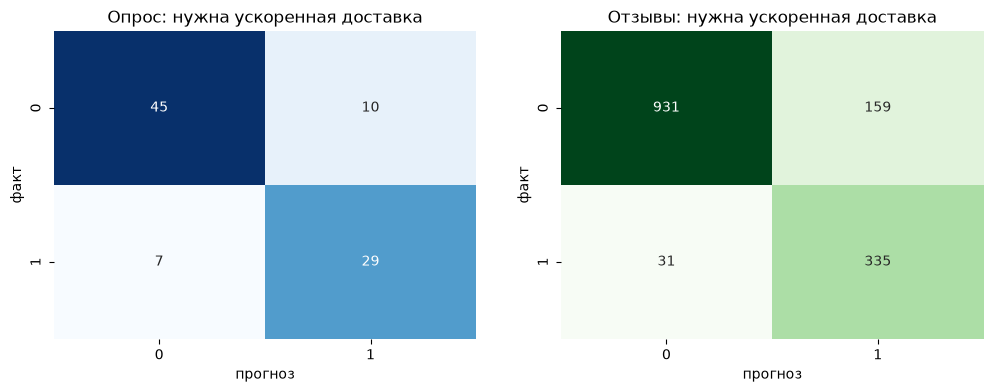

In [150]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

survey_accelerated_model = fit_and_report(
    best_models["ускорение", "RandomForest"], X_train, acc_train, X_test, acc_test,
    ["Стандартная", "Ускоренная"], "Опрос: нужна ускоренная доставка", "Blues", axes[0],
)

rev_train, rev_test, rev_acc_train, rev_acc_test = train_test_split(
    review_text, y_review_accelerated, test_size=0.25, random_state=RANDOM_STATE, stratify=y_review_accelerated
)
review_accelerated_model = fit_and_report(
    review_pipeline(LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    rev_train, rev_acc_train, rev_test, rev_acc_test,
    ["Не ускорять", "Ускорять"], "Отзывы: нужна ускоренная доставка", "Greens", axes[1],
)

plt.show()

Опрос: риск недовольства
              precision    recall  f1-score   support

   Нет риска       0.95      0.90      0.92        67
        Риск       0.75      0.88      0.81        24

    accuracy                           0.89        91
   macro avg       0.85      0.89      0.87        91
weighted avg       0.90      0.89      0.89        91

Отзывы: риск низкой оценки
              precision    recall  f1-score   support

  Оценка 3-5       0.97      0.88      0.92       677
  Оценка 1-2       0.91      0.98      0.94       779

    accuracy                           0.93      1456
   macro avg       0.94      0.93      0.93      1456
weighted avg       0.94      0.93      0.93      1456



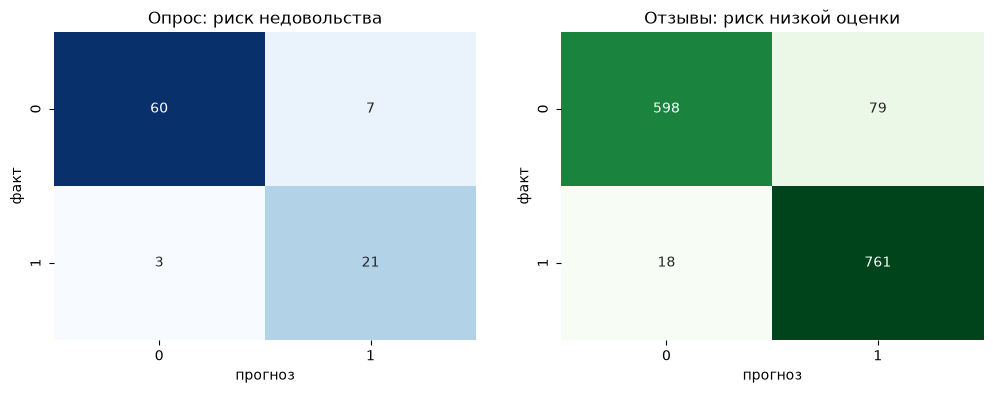

In [151]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

survey_dissatisfaction_model = fit_and_report(
    best_models["недовольство", "LogReg"], X_train, dis_train, X_test, dis_test,
    ["Нет риска", "Риск"], "Опрос: риск недовольства", "Blues", axes[0],
)

rev_train_d, rev_test_d, rev_dis_train, rev_dis_test = train_test_split(
    review_text, y_review_dissatisfaction, test_size=0.25, random_state=RANDOM_STATE, stratify=y_review_dissatisfaction
)
fit_and_report(
    review_pipeline(LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    rev_train_d, rev_dis_train, rev_test_d, rev_dis_test,
    ["Оценка 3-5", "Оценка 1-2"], "Отзывы: риск низкой оценки", "Greens", axes[1],
)

plt.show()

## Что влияет на прогноз

Модель полезна, только если понятно, на что она смотрит. Для опроса считаем permutation importance —
насколько падает ROC-AUC, если перемешать один признак. Для отзывов смотрим слова с наибольшим весом
у линейной модели.

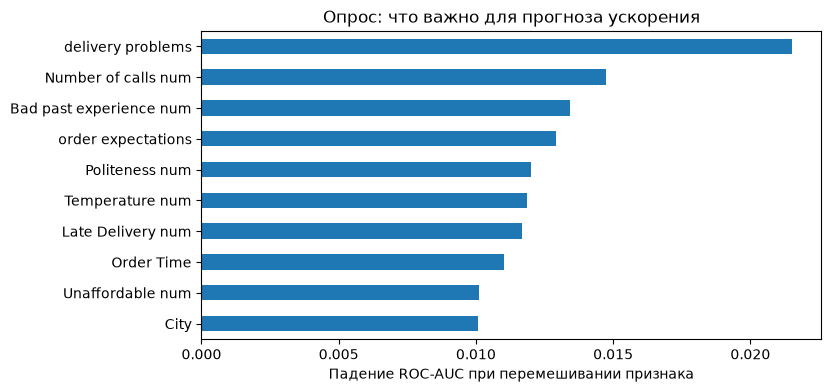

In [152]:
importance = permutation_importance(
    survey_accelerated_model, X_test, acc_test, n_repeats=10, random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=-1
)
top_features = pd.Series(importance.importances_mean, index=X_survey.columns).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 4))
top_features[::-1].plot(kind="barh", ax=ax)
ax.set(title="Опрос: что важно для прогноза ускорения", xlabel="Падение ROC-AUC при перемешивании признака", ylabel="")
plt.show()

In [153]:
vocabulary = np.array(review_accelerated_model.named_steps["tfidf"].get_feature_names_out())
weights = review_accelerated_model.named_steps["model"].coef_[0]
top_words = vocabulary[np.argsort(weights)[-15:][::-1]]

# самые важные слова
top_words

array(['часа', 'час', 'долго', 'ужасная', 'ужасное', 'ужасно', 'ужас',
       'долгая', 'часов', 'холодная', 'ужасный', 'ждал', 'ужасный сервис',
       'холодное', 'холодную'], dtype=object)

На опросе для ускорение наиболее важны проблемы с доставкой и ожидания от заказа; в отзывах — слова про время и температуру еды: "час", "долго", "ждал", "холодная", "ужас".
Из-за способа разметки целевой переменной получилось так, что модель во многом воспроизводит словарь, которым размечена цель. То есть как детектор жалоб на скорость она работает, но это не независимая проверка.

## Сравнение двух источников

Опрос и отзывы проверяют одни и те же решения на разных данных: опрос — ожидания до заказа, отзывы — реакцию после. Сводим лучшие результаты в таблицу. Числа в ней — средние по кросс-валидации, и метрики (на опросе ROC-AUC, на отзывах F1).

In [154]:
comparison = pd.DataFrame([
    {"task": "ускорение", "dataset": "опрос", "best_model": survey_accelerated.loc[0, "model"], "metric": "ROC-AUC", "cv_score": survey_accelerated.loc[0, "roc_auc"]},
    {"task": "ускорение", "dataset": "отзывы", "best_model": review_accelerated.loc[0, "model"], "metric": "F1", "cv_score": review_accelerated.loc[0, "f1"]},
    {"task": "недовольство", "dataset": "опрос", "best_model": survey_dissatisfaction.loc[0, "model"], "metric": "ROC-AUC", "cv_score": survey_dissatisfaction.loc[0, "roc_auc"]},
    {"task": "недовольство", "dataset": "отзывы", "best_model": review_dissatisfaction.loc[0, "model"], "metric": "F1", "cv_score": review_dissatisfaction.loc[0, "f1"]},
])
comparison

,task,dataset,best_model,metric,cv_score
0,ускорение,опрос,RandomForest,ROC-AUC,0.870
1,ускорение,отзывы,LogReg,F1,0.779
2,недовольство,опрос,GradientBoosting,ROC-AUC,0.954
3,недовольство,отзывы,LogReg,F1,0.929


Видно, что задачи решаются на обоих источниках, но больше подходят для них разные модели: на структурированном опросе впереди нелинейные модели, на тексте — линейная логрегрессия.

## Порог решения и стоимость ошибки

Ошибочно ускорить доставку = потратить деньги, пропустить нетерпеливого клиента = риск его потерять и тоже потерять деньги. Сдвигая порог для стоимости ошибок, мы меняем баланс precision и recall под конкретную экономику. График показывает, как ведут себя precision и recall класса "ускорять" при разных порогах.

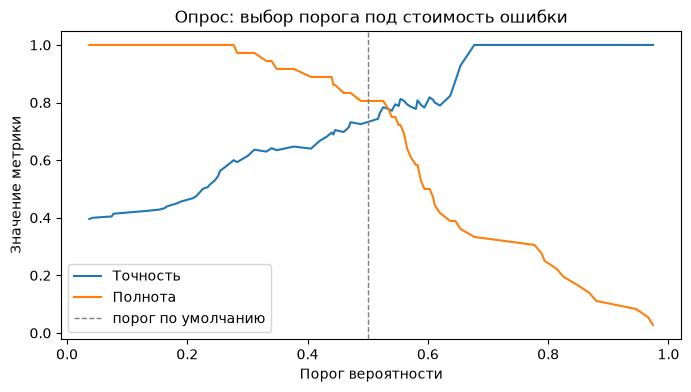

In [155]:
proba = survey_accelerated_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(acc_test, proba)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, precision[:-1], label="Точность")
ax.plot(thresholds, recall[:-1], label="Полнота")
ax.axvline(0.5, color="grey", linestyle="--", linewidth=1, label="порог по умолчанию")
ax.set(title="Опрос: выбор порога под стоимость ошибки", xlabel="Порог вероятности", ylabel="Значение метрики")
ax.legend()
plt.show()

## Бизнес-правило выбора доставки

Финальное решение по клиенту собирается из двух прогнозов на одном и том же наборе: один отвечает за логистику (ускорять или нет), второй — за риск (нужен ли контроль поддержки). На их пересечении выходит четыре сценария.

In [156]:
decisions = X_test[["Age", "Gender", "Occupation", "City"]].copy()
decisions["accelerated"] = survey_accelerated_model.predict(X_test)
decisions["dissatisfaction"] = survey_dissatisfaction_model.predict(X_test)

conditions = [
    (decisions["accelerated"] == 1) & (decisions["dissatisfaction"] == 1),
    decisions["accelerated"] == 1,
    decisions["dissatisfaction"] == 1,
]
choices = [
    "Ускоренная доставка + контроль поддержки",
    "Ускоренная доставка",
    "Обычная доставка + контроль качества",
]
decisions["recommendation"] = np.select(conditions, choices, default="Обычная доставка")

decisions["recommendation"].value_counts()

recommendation
Обычная доставка                            45
Ускоренная доставка + контроль поддержки    21
Ускоренная доставка                         18
Обычная доставка + контроль качества         7
Name: count, dtype: int64

In [157]:
decisions.head(12)

,Age,Gender,Occupation,City,accelerated,dissatisfaction,recommendation
115,25,Female,Employee,Sydney,1,1,Ускоренная доставка + контроль поддержки
28,23,Female,Employee,Sydney,0,0,Обычная доставка
18,25,Male,Student,Melbourne,0,0,Обычная доставка
19,21,Female,Student,Brisbane,0,0,Обычная доставка
245,31,Male,Employee,Melbourne,1,1,Ускоренная доставка + контроль поддержки
211,24,Female,Employee,Brisbane,0,0,Обычная доставка
169,27,Male,Employee,Brisbane,0,0,Обычная доставка
318,27,Male,Employee,Sydney,1,0,Ускоренная доставка
189,31,Female,Employee,Adelaide,0,0,Обычная доставка
332,29,Male,Employee,Perth,1,1,Ускоренная доставка + контроль поддержки


## Что нужно для внедрения

В опросе нет логов заказов, и он вообще не для россии проводился. Так что для нормальной версии понадобятся данные, которых у нас сейчас нет:

- `user_id` и история заказов клиента;
- обещанное и фактическое время доставки;
- тип назначенного курьера и стоимость доставки для платформы;
- ресторан, район, расстояние, погода, время суток;
- отмены, жалобы, оценки, повторные заказы и сам факт ухода клиента.

С нормальными данными вторую задачу стоит размечать не правилом, а реальным последствием задержки.

## Итог

В проекте решены две бизнес-задачи: определить, кому нужна ускоренная доставка, и определить, где есть риск сильного недовольства или потери клиента.

Обе задачи проверены на двух источниках данных: на опросном датасете и на собранных реальных отзывах Яндекс Еды и Delivery Club из Google Play.